# Basic EDA 

In [1]:
# Imports & setup
%matplotlib inline

from pathlib import Path
import re, random, sys
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Image file extensions to consider
IMG_EXTS = {'.jpg', '.jpeg', '.png'}

In [2]:
# Set image directories
TRAIN_DIR = "/mnt/lfs0/Database/AIML_Lab/cxr-multi-label-classification/train_images"  
VALID_DIR = "/mnt/lfs0/Database/AIML_Lab/cxr-multi-label-classification/val_images"  
TEST_DIR = "/mnt/lfs0/Database/AIML_Lab/cxr-multi-label-classification/test_images"  

TRAIN_DIR = Path(TRAIN_DIR)
VALID_DIR = Path(VALID_DIR)
TEST_DIR = Path(TEST_DIR)

print("Train dir:", TRAIN_DIR)
print("Valid dir:", VALID_DIR)
print("Test dir:", TEST_DIR)


Train dir: /mnt/lfs0/Database/AIML_Lab/cxr-multi-label-classification/train_images
Valid dir: /mnt/lfs0/Database/AIML_Lab/cxr-multi-label-classification/val_images
Test dir: /mnt/lfs0/Database/AIML_Lab/cxr-multi-label-classification/test_images


In [3]:
# Metadata for CSV-driven exploration
DATA_ROOT = TRAIN_DIR.parent

CSV_PATHS = {
    "train": DATA_ROOT / "train_data.csv",
    "val": DATA_ROOT / "val_data.csv",
}

CLASS_LABELS = ["normal", "bacteria", "virus", "COVID-19"]

SAMPLE_IMAGES = {
    "train": {
        "normal": "1006.jpeg",
        "bacteria": "3953.jpeg",
        "virus": "3766.jpeg",
        "COVID-19": "46.png",
    },
    "val": {
        "normal": "1138.jpeg",
        "bacteria": "3337.jpeg",
        "virus": "4796.jpeg",
        "COVID-19": "49.png",
    },
}

In [4]:
# Helper utilities for counting and visualization
def summarize_split(csv_path, class_labels):
    """Return the total count per class for a CSV split."""
    df = pd.read_csv(csv_path)
    totals = df[class_labels].sum().astype(int)
    totals.index.name = "class"
    return totals

def build_counts_table(csv_paths):
    counts = {split: summarize_split(path, CLASS_LABELS) for split, path in csv_paths.items()}
    counts_df = pd.DataFrame(counts)
    return counts_df.loc[CLASS_LABELS]

def plot_class_counts(counts_df):
    ordered = counts_df.loc[CLASS_LABELS]
    idx = np.arange(len(CLASS_LABELS))
    splits = ordered.columns.tolist()
    width = 0.8 / len(splits)
    max_height = ordered.to_numpy().max()
    text_offset = max(max_height * 0.01, 1) if max_height else 1

    fig, ax = plt.subplots(figsize=(8, 4))
    for i, split in enumerate(splits):
        offsets = -0.4 + i * width + width / 2
        ax.bar(idx + offsets, ordered[split], width=width, label=split.title())
        for j, value in enumerate(ordered[split]):
            ax.text(idx[j] + offsets, value + text_offset, str(int(value)), ha="center", va="bottom")

    tick_labels = ["COVID-19" if label == "COVID-19" else label.title() for label in CLASS_LABELS]
    ax.set_xticks(idx)
    ax.set_xticklabels(tick_labels)
    ax.set_ylabel("# Images")
    ax.set_title("Train and Validation label counts")
    ax.legend()
    plt.tight_layout()
    plt.show()

,train,val
class,,
normal,1072,189
bacteria,1888,333
virus,1018,180
COVID-19,39,7


Train total images: 4017
Val total images: 709


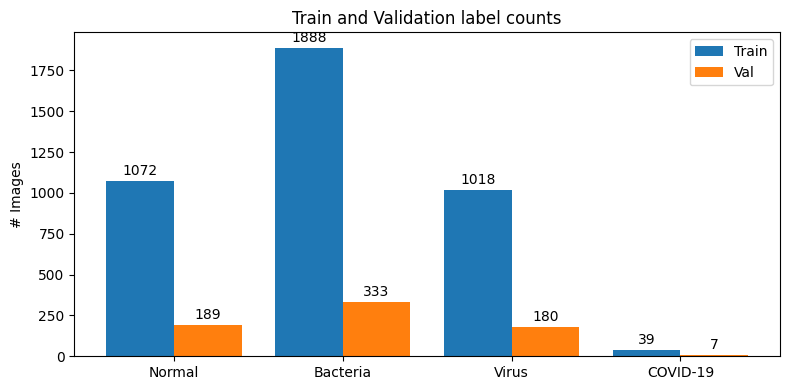

In [5]:
# === Label counts from CSVs ===
counts_table = build_counts_table(CSV_PATHS)
display(counts_table)

for split, values in counts_table.items():
    total = int(values.sum())
    print(f"{split.title()} total images: {total}")

plot_class_counts(counts_table)

In [6]:
def show_samples(split_name, base_dir, file_map):
    split_label = split_name.title()
    fig, axes = plt.subplots(1, len(CLASS_LABELS), figsize=(12, 3))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    for ax, label in zip(axes, CLASS_LABELS):
        display_label = "COVID-19" if label == "COVID-19" else label.title()
        file_name = file_map.get(label)
        img_path = base_dir / file_name if file_name else None
        if img_path and img_path.exists():
            image = Image.open(img_path).convert("RGB")
            ax.imshow(image)
            ax.set_title(display_label, fontsize=10)
        else:
            ax.text(0.5, 0.5, "Missing image", ha="center", va="center")
            ax.set_title(f"{display_label} (missing)", fontsize=10)
        ax.axis("off")

    fig.suptitle(f"{split_label} samples", y=1.05)
    plt.tight_layout()
    plt.show()

    print(f"{split_label} sample files:")
    for label in CLASS_LABELS:
        fname = file_map.get(label, "(not set)")
        print(f"  - {label}: {fname}")

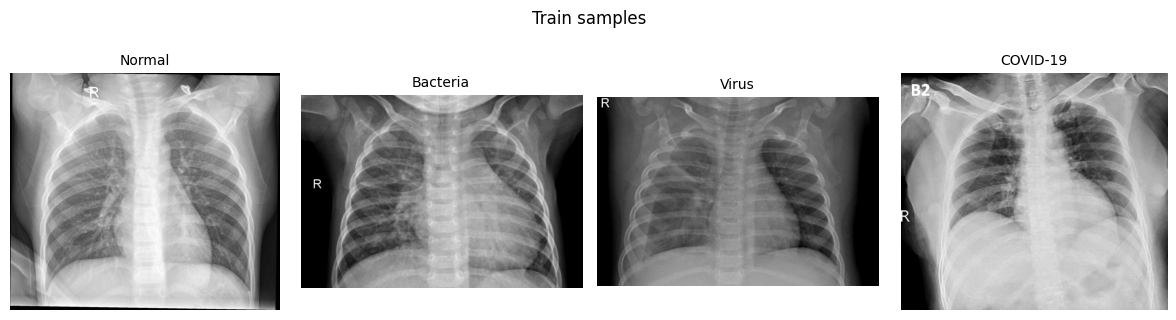

Train sample files:
  - normal: 1006.jpeg
  - bacteria: 3953.jpeg
  - virus: 3766.jpeg
  - COVID-19: 46.png


In [7]:
# === Train samples ===
show_samples("train", TRAIN_DIR, SAMPLE_IMAGES["train"])

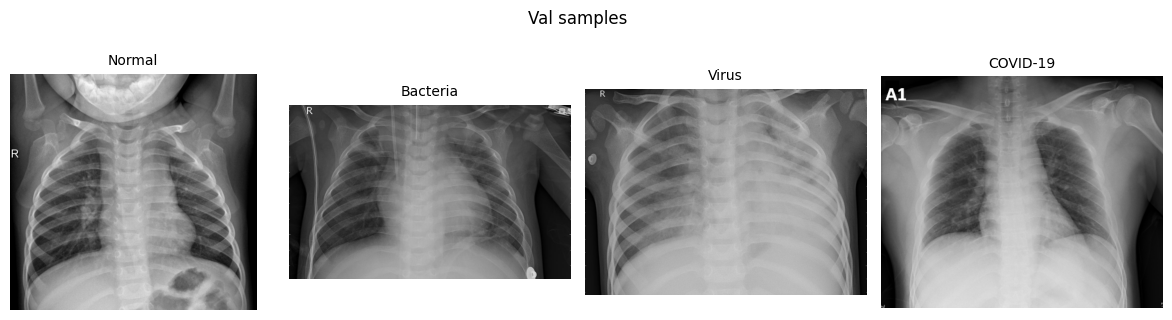

Val sample files:
  - normal: 1138.jpeg
  - bacteria: 3337.jpeg
  - virus: 4796.jpeg
  - COVID-19: 49.png


In [8]:
# === Validation samples ===
show_samples("val", VALID_DIR, SAMPLE_IMAGES["val"])

# Preprocessing Pipeline (CLAHE + border cleanup)
Implements the requested CLAHE, black border removal, text masking, and coarse lung crop so that every image is normalized before augmentation.


In [9]:
from dataclasses import dataclass
from typing import Tuple

import cv2
import numpy as np
from PIL import Image

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

@dataclass
class PreprocessConfig:
    clahe_clip_limit: float = 2.0
    clahe_tile_grid_size: Tuple[int, int] = (8, 8)
    border_threshold: int = 5
    border_min_fraction: float = 0.03
    text_threshold: int = 235
    text_border_ratio: float = 0.08
    lung_min_area_ratio: float = 0.35
    lung_pad_ratio: float = 0.04

DEFAULT_PREPROCESS_CFG = PreprocessConfig()


def _to_gray_np(image: Image.Image) -> np.ndarray:
    arr = np.array(image)
    if arr.ndim == 3:
        arr = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    return arr.astype(np.uint8)


def _crop_black_borders(gray: np.ndarray, cfg: PreprocessConfig) -> np.ndarray:
    mask = gray > cfg.border_threshold
    row_hits = np.where(mask.sum(axis=1) > cfg.border_min_fraction * gray.shape[1])[0]
    col_hits = np.where(mask.sum(axis=0) > cfg.border_min_fraction * gray.shape[0])[0]
    if row_hits.size == 0 or col_hits.size == 0:
        return gray
    top, bottom = row_hits[0], row_hits[-1]
    left, right = col_hits[0], col_hits[-1]
    pad = int(min(gray.shape) * 0.01)
    top = max(top - pad, 0)
    bottom = min(bottom + pad, gray.shape[0] - 1)
    left = max(left - pad, 0)
    right = min(right + pad, gray.shape[1] - 1)
    return gray[top:bottom + 1, left:right + 1]


def _mask_corner_artifacts(gray: np.ndarray, cfg: PreprocessConfig) -> np.ndarray:
    border = max(int(min(gray.shape) * cfg.text_border_ratio), 1)
    mask = np.zeros_like(gray, dtype=bool)
    mask[:border, :] = True
    mask[-border:, :] = True
    mask[:, :border] = True
    mask[:, -border:] = True
    text_mask = (gray >= cfg.text_threshold) & mask
    if not text_mask.any():
        return gray
    filled = gray.copy()
    median_val = int(np.median(gray))
    filled[text_mask] = median_val
    return filled


def _coarse_lung_crop(gray: np.ndarray, cfg: PreprocessConfig) -> np.ndarray:
    inv = cv2.bitwise_not(gray)
    blur = cv2.GaussianBlur(inv, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((7, 7), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return gray
    contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(contour)
    if area < cfg.lung_min_area_ratio * gray.size:
        return gray
    x, y, w, h = cv2.boundingRect(contour)
    pad = int(min(gray.shape) * cfg.lung_pad_ratio)
    y0 = max(y - pad, 0)
    x0 = max(x - pad, 0)
    y1 = min(y + h + pad, gray.shape[0])
    x1 = min(x + w + pad, gray.shape[1])
    return gray[y0:y1, x0:x1]


def _apply_clahe(gray: np.ndarray, cfg: PreprocessConfig) -> np.ndarray:
    clahe = cv2.createCLAHE(clipLimit=cfg.clahe_clip_limit, tileGridSize=cfg.clahe_tile_grid_size)
    return clahe.apply(gray)


def preprocess_cxr(image: Image.Image, cfg: PreprocessConfig = DEFAULT_PREPROCESS_CFG) -> Image.Image:
    gray = _to_gray_np(image)
    gray = _crop_black_borders(gray, cfg)
    gray = _mask_corner_artifacts(gray, cfg)
    gray = _coarse_lung_crop(gray, cfg)
    gray = _apply_clahe(gray, cfg)
    return Image.fromarray(gray).convert("RGB")

## Multi-label dataset + dataloaders (step 1/plan)
Dataset reads the CSV meta, applies preprocessing, and builds WeightedRandomSampler-driven loaders 

In [10]:
import os
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.v2 as v2
import torchvision.transforms.v2.functional as v2F
from torchvision.transforms import InterpolationMode


class MultiLabelCXRDataset(Dataset):
    def __init__(self, csv_path, image_dir, transform=None, preprocess_cfg=None):
        self.csv_path = Path(csv_path)
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.preprocess_cfg = preprocess_cfg or DEFAULT_PREPROCESS_CFG

        df = pd.read_csv(self.csv_path)
        missing_cols = [c for c in CLASS_LABELS if c not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing columns {missing_cols} in {self.csv_path}")

        self.file_names = df["new_filename"].tolist()
        self.targets = df[CLASS_LABELS].values.astype(np.float32)

        nonexistent = [fname for fname in self.file_names if not (self.image_dir / fname).exists()]
        if nonexistent:
            raise FileNotFoundError(f"{len(nonexistent)} files listed in {self.csv_path} were not found. Example: {nonexistent[:3]}")

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        path = self.image_dir / self.file_names[idx]
        target = torch.from_numpy(self.targets[idx])
        image = Image.open(path).convert("L")
        image = preprocess_cxr(image, self.preprocess_cfg)
        if self.transform:
            image = self.transform(image)
        return image, target

    def class_counts(self):
        return self.targets.sum(axis=0)


def build_transforms(image_size=512, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    resize_target = int(image_size * 1.1)
    train_tfms = v2.Compose([
        v2.Resize(resize_target, interpolation=InterpolationMode.BICUBIC),
        v2.RandomResizedCrop(image_size, scale=(0.85, 1.0), interpolation=InterpolationMode.BICUBIC),
        v2.RandomHorizontalFlip(p=0.2),
        v2.RandomAffine(degrees=5, translate=(0.05, 0.05), interpolation=InterpolationMode.BILINEAR, fill=0),
        v2.RandomPerspective(distortion_scale=0.05, p=0.1, interpolation=InterpolationMode.BILINEAR, fill=0),
        v2.ColorJitter(brightness=0.12, contrast=0.12),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean, std),
    ])
    eval_tfms = v2.Compose([
        v2.Resize(resize_target, interpolation=InterpolationMode.BICUBIC),
        v2.CenterCrop(image_size),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean, std),
    ])
    return train_tfms, eval_tfms


def build_weighted_sampler(dataset: MultiLabelCXRDataset, intensity: float = 1.0):
    counts = dataset.class_counts().astype(np.float64)
    class_weights = 1.0 / (counts + 1e-6)
    sample_weights = dataset.targets @ class_weights
    sample_weights = sample_weights / sample_weights.sum()
    intensity = float(np.clip(intensity, 0.0, 1.0))
    if intensity < 1.0:
        uniform = np.full_like(sample_weights, 1.0 / len(sample_weights))
        sample_weights = intensity * sample_weights + (1.0 - intensity) * uniform
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(dataset),
        replacement=True,
    )
    return sampler


def describe_counts(name, counts):
    summary = {label: int(counts[i]) for i, label in enumerate(CLASS_LABELS)}
    print(f"{name} class counts: {summary}")


IMG_SIZE = 512
BATCH_SIZE = 64
NUM_WORKERS = min(8, os.cpu_count() or 2)
PREPROCESS_CFG = PreprocessConfig(clahe_clip_limit=2.5, lung_min_area_ratio=0.3, lung_pad_ratio=0.05)
USE_WEIGHTED_SAMPLER = False  # CB-Focal works best without oversampling; flip to True for CE runs
SAMPLER_INTENSITY = 0.3  # if enabling sampler, blend 0 (uniform) to 1 (full inverse freq)


def build_dataloaders(
    image_size: int = IMG_SIZE,
    batch_size: int = BATCH_SIZE,
    num_workers: int = NUM_WORKERS,
    use_weighted_sampler: bool = USE_WEIGHTED_SAMPLER,
    report_counts: bool = True,
):
    train_tfms, eval_tfms = build_transforms(image_size)
    train_ds = MultiLabelCXRDataset(CSV_PATHS["train"], TRAIN_DIR, transform=train_tfms,
                                    preprocess_cfg=PREPROCESS_CFG)
    val_ds = MultiLabelCXRDataset(CSV_PATHS["val"], VALID_DIR, transform=eval_tfms,
                                  preprocess_cfg=PREPROCESS_CFG)

    train_counts_local = train_ds.class_counts()
    val_counts_local = val_ds.class_counts()
    if report_counts:
        describe_counts("Train", train_counts_local)
        describe_counts("Val", val_counts_local)

    train_sampler = build_weighted_sampler(train_ds, SAMPLER_INTENSITY) if use_weighted_sampler else None
    if train_sampler is not None:
        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=train_sampler,
                                  num_workers=num_workers, pin_memory=True)
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                                  num_workers=num_workers, pin_memory=True)

    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, train_counts_local, val_counts_local


base_train_ds = MultiLabelCXRDataset(CSV_PATHS["train"], TRAIN_DIR, transform=None,
                                     preprocess_cfg=PREPROCESS_CFG)
base_val_ds = MultiLabelCXRDataset(CSV_PATHS["val"], VALID_DIR, transform=None,
                                   preprocess_cfg=PREPROCESS_CFG)
train_counts = base_train_ds.class_counts()
val_counts = base_val_ds.class_counts()
describe_counts("Train", train_counts)
describe_counts("Val", val_counts)
print("Weighted sampler default:", "enabled" if USE_WEIGHTED_SAMPLER else "disabled")


class TestCXRDataset(Dataset):
    def __init__(self, csv_path, image_dir, transform=None, preprocess_cfg=None):
        self.csv_path = Path(csv_path)
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.preprocess_cfg = preprocess_cfg or DEFAULT_PREPROCESS_CFG

        df = pd.read_csv(self.csv_path)
        self.file_names = df["new_filename"].tolist()

        missing = [fname for fname in self.file_names if not (self.image_dir / fname).exists()]
        if missing:
            raise FileNotFoundError(f"{len(missing)} test files listed in {self.csv_path} were not found. Example: {missing[:3]}")

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        path = self.image_dir / self.file_names[idx]
        image = Image.open(path).convert("L")
        image = preprocess_cxr(image, self.preprocess_cfg)
        if self.transform:
            image = self.transform(image)
        return image, self.file_names[idx]



Train class counts: {'normal': 1072, 'bacteria': 1888, 'virus': 1018, 'COVID-19': 39}
Val class counts: {'normal': 189, 'bacteria': 333, 'virus': 180, 'COVID-19': 7}
Weighted sampler default: disabled


## Training device


In [11]:
import sys, os, platform, time
import torch, torchvision

print("Python:", sys.version)
print("OS:", platform.platform())
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("CUDA device name:", torch.cuda.get_device_name(0))
else:
    print("NO GPUs; Run on CPU instead.")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Python: 3.10.18 | packaged by conda-forge | (main, Jun  4 2025, 14:45:41) [GCC 13.3.0]
OS: Linux-6.8.0-87-generic-x86_64-with-glibc2.35
PyTorch: 2.8.0+cu128
Torchvision: 0.23.0+cu128
CUDA available: True
CUDA device count: 2
CUDA device name: NVIDIA RTX 6000 Ada Generation
Using device: cuda


In [12]:
from typing import Dict, Tuple, Optional
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

from torchvision import models
from transformers import get_cosine_schedule_with_warmup
import ttach as tta

# Config 
NUM_CLASSES = 4
CLASS_NAMES = ["normal", "bacteria", "virus", "COVID-19"]

MODEL_SPECS = {
    "swin_v2_s": {"img_size": 512},
    "vit_b_32": {"img_size": 224},
    "maxvit_t": {"img_size": 224},
    "convnext_base": {"img_size": 512},
    "efficientnetv2_s": {"img_size": 512},
    "densenet161": {"img_size": 512},
}


def get_model_img_size(name: str, default: int = IMG_SIZE) -> int:
    spec = MODEL_SPECS.get(name.lower())
    return spec.get("img_size", default) if spec else default


MODEL_CANDIDATES = [
#    ("DenseNet-161", "densenet161"),
    ("EfficientNetV2-S", "efficientnetv2_s"),
    ("ConvNeXt-Base", "convnext_base"),
#    ("ViT-B/32", "vit_b_32"),
    ("Swin-V2_s", "swin_v2_s"),
#    ("MaxViT-T", "maxvit_t"),
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 80
LR = 1e-4
WEIGHT_DECAY = 0.03
WARMUP_RATIO = 0.05
MAX_GRAD_NORM = 1.0
LABEL_SMOOTHING = 0.05
USE_AMP = DEVICE.type == "cuda"
# Loss config
LOSS_NAME = "cb_focal"  # cb_focal, balms, or ce
CB_BETA = 0.999
CB_GAMMA = 1.0
# CutMix
USE_CUTMIX = True
CUTMIX_ALPHA = 0.5  
CUTMIX_PROB = 0.3
# Calibration / TTA
TEMP_GRID = [0.75, 1.0, 1.25, 1.5]
BIAS_GRID = [-0.5, -0.25, 0.0, 0.25, 0.5]
USE_TTA = True
TTA_MODE = "hflip"  # hflip only (no vertical) via ttach
TARGET_PRIORS = None  # Optional: list/tuple of 4 test priors if known

In [13]:
import torch.nn.functional as F


def _safe_class_counts(counts):
    values = torch.as_tensor(counts, dtype=torch.float32)
    return torch.clamp(values, min=1.0)


class ClassBalancedFocalLoss(nn.Module):
    def __init__(self, counts, beta=0.9999, gamma=2.0, eps=1e-7):
        super().__init__()
        counts = _safe_class_counts(counts)
        effective = 1.0 - torch.pow(beta, counts)
        weights = (1.0 - beta) / effective
        weights = weights / weights.sum() * len(weights)
        self.register_buffer("weights", weights)
        self.gamma = gamma
        self.eps = eps

    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        weights = self.weights.to(logits.device)

        if target.ndim == 1:
            idx = torch.arange(logits.size(0), device=logits.device)
            pt = probs[idx, target].clamp(min=self.eps, max=1.0)
            focal_factor = (1.0 - pt).pow(self.gamma)
            loss = -weights[target] * focal_factor * log_probs[idx, target]
            return loss.mean()

        # Soft targets from CutMix/MixUp: use per-class focal weighting
        target = target.to(logits.device)
        focal_factor = (1.0 - probs).pow(self.gamma)
        loss = -(target * weights.unsqueeze(0) * focal_factor * log_probs).sum(dim=1)
        return loss.mean()


def build_loss_fn(name: str, counts, label_smoothing: float = 0.0) -> nn.Module:
    key = (name or "cb_focal").lower()
    if key == "cb_focal":
        return ClassBalancedFocalLoss(counts, beta=CB_BETA, gamma=CB_GAMMA)
    return nn.CrossEntropyLoss(label_smoothing=label_smoothing)

In [14]:
def ensure_class_indices(targets: torch.Tensor) -> torch.Tensor:
    """Accept either indices [B] or one-hot [B,C], returns indices [B]."""
    if targets.ndim == 2:
        return targets.argmax(dim=1)
    return targets.long()


def macro_roc_auc_multiclass(y_true_idx: np.ndarray, y_prob: np.ndarray) -> float:
    """Compute macro ROC-AUC for multi-class (ovr). y_true_idx shape [N], y_prob [N,C]."""
    N, C = y_prob.shape
    y_true_oh = np.eye(C, dtype=np.int32)[y_true_idx]
    try:
        return roc_auc_score(y_true_oh, y_prob, average="macro", multi_class="ovr")
    except Exception:
        return float("nan")


def plot_history(history: Dict[str, list], title_prefix: str = "Model") -> None:
    """Plot loss, AUC, and macro-F1 curves for training/validation."""
    epochs = np.arange(1, len(history.get("train_loss", [])) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    plt.plot(epochs, history["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"{title_prefix} — Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_auc"], label="train AUC")
    plt.plot(epochs, history["val_auc"], label="val AUC")
    plt.xlabel("epoch")
    plt.ylabel("macro ROC-AUC")
    plt.title(f"{title_prefix} — AUC")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["val_f1"], label="val macro-F1", color="tab:green")
    plt.xlabel("epoch")
    plt.ylabel("macro-F1")
    plt.title(f"{title_prefix} — Macro-F1")
    plt.legend()
    plt.grid(True)
    plt.show()


def build_tta_wrapper(model: nn.Module, mode: str = "hflip") -> nn.Module:
    """Wrap model with ttach TTA transforms; defaults to horizontal flip."""
    tta_mode = (mode or "hflip").lower()
    if tta_mode == "hflip":
        transforms = tta.aliases.hflip_transform()
    elif tta_mode == "d4":
        transforms = tta.aliases.d4_transform()
    else:
        print(f"[TTA] Unsupported mode '{mode}', falling back to hflip.")
        transforms = tta.aliases.hflip_transform()
    return tta.ClassificationTTAWrapper(model, transforms)

In [15]:
def resize_vit_pos_embed_(model, new_img_size: int):
    patch = getattr(model, "patch_size", None)
    if patch is None and hasattr(model, "conv_proj"):
        patch = model.conv_proj.stride[0]
    assert patch is not None, "Could not detect ViT patch size"

    pos = getattr(model, "pos_embed", None)
    if pos is None:
        encoder = getattr(model, "encoder", None)
        if encoder is not None:
            pos = getattr(encoder, "pos_embedding", None)
    assert pos is not None, "Could not find the positional embedding tensor"

    with torch.no_grad():
        cls_pos = pos[:, :1, :]
        patch_pos = pos[:, 1:, :]
        n = patch_pos.shape[1]
        gs_old = int(n ** 0.5)
        gs_new = new_img_size // patch

        patch_pos = patch_pos.reshape(1, gs_old, gs_old, -1).permute(0, 3, 1, 2)
        patch_pos = torch.nn.functional.interpolate(
            patch_pos, size=(gs_new, gs_new), mode="bicubic", align_corners=False
        )
        patch_pos = patch_pos.permute(0, 2, 3, 1).reshape(1, gs_new * gs_new, -1)
        new_pos = torch.cat([cls_pos, patch_pos], dim=1)
        if hasattr(model, "pos_embed"):
            model.pos_embed[:] = new_pos
        else:
            model.encoder.pos_embedding[:] = new_pos


def build_model(model_name: str, num_classes: int = NUM_CLASSES, image_size: Optional[int] = None) -> nn.Module:
    """Create a torchvision model with an ImageNet head replaced for our 4 classes."""
    name = model_name.lower()
    image_size = image_size or get_model_img_size(name)
    if name == "densenet161":
        weights = models.DenseNet161_Weights.IMAGENET1K_V1
        model = models.densenet161(weights=weights)
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)
    elif name == "efficientnetv2_s":
        weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
        model = models.efficientnet_v2_s(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
    elif name == "convnext_base":
        weights = models.ConvNeXt_Base_Weights.IMAGENET1K_V1
        model = models.convnext_base(weights=weights)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
    elif name == "vit_b_32":
        weights = models.ViT_B_32_Weights.IMAGENET1K_V1
        model = models.vit_b_32(weights=weights)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_classes)
        resize_vit_pos_embed_(model, new_img_size=image_size)
    elif name == "swin_v2_s":
        weights = models.Swin_V2_S_Weights.IMAGENET1K_V1
        model = models.swin_v2_s(weights=weights)
        in_features = model.head.in_features
        model.head = nn.Linear(in_features, num_classes)
    elif name == "maxvit_t":
        weights = models.MaxVit_T_Weights.IMAGENET1K_V1
        model = models.maxvit_t(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
    else:
        raise ValueError(f"Unsupported model name: {model_name}")
    return model.to(DEVICE)

In [16]:
def ensure_class_indices(targets: torch.Tensor) -> torch.Tensor:
    """Accept either indices [B] or one-hot [B,C], returns indices [B]."""
    if targets.ndim == 2:
        return targets.argmax(dim=1)
    return targets.long()


def macro_roc_auc_multiclass(y_true_idx: np.ndarray, y_prob: np.ndarray) -> float:
    """Compute macro ROC-AUC for multi-class (ovr). y_true_idx shape [N], y_prob [N,C]."""
    N, C = y_prob.shape
    y_true_oh = np.eye(C, dtype=np.int32)[y_true_idx]
    try:
        return roc_auc_score(y_true_oh, y_prob, average="macro", multi_class="ovr")
    except Exception:
        return float("nan")

def train_one_epoch(
    model: nn.Module,
    loader,
    optimizer,
    scheduler,
    scaler: Optional[torch.amp.GradScaler],
    loss_fn: nn.Module,
    max_grad_norm: float = 1.0,
) -> Tuple[float, float]:
    """One training epoch. Returns (avg_loss, macro_auc)."""
    model.train()

    total_loss, total_examples = 0.0, 0
    prob_chunks, label_chunks = [], []
    cutmix = v2.CutMix(num_classes=NUM_CLASSES, alpha=CUTMIX_ALPHA) if USE_CUTMIX else None

    pbar = tqdm(loader, leave=False)
    for images, targets in pbar:
        images = images.to(DEVICE, non_blocking=True)
        targets_idx = ensure_class_indices(targets.to(DEVICE, non_blocking=True))

        if cutmix and np.random.rand() < CUTMIX_PROB:
            images, mix_targets = cutmix(images, targets_idx)
        else:
            mix_targets = targets_idx

        optimizer.zero_grad(set_to_none=True)

        if USE_AMP:
            with torch.amp.autocast(device_type="cuda"):
                logits = model(images)
                loss = loss_fn(logits, mix_targets)
        else:
            logits = model(images)
            loss = loss_fn(logits, mix_targets)

        if scaler is not None and USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.detach().item() * images.size(0)
        total_examples += images.size(0)

        with torch.no_grad():
            probs = torch.softmax(logits, dim=1).detach().cpu()
            prob_chunks.append(probs)
            label_chunks.append(targets_idx.detach().cpu())

        pbar.set_description(f"train loss {loss.detach().item():.4f}")

    avg_loss = total_loss / max(total_examples, 1)
    if prob_chunks:
        y_prob = torch.cat(prob_chunks).numpy()
        y_true = torch.cat(label_chunks).numpy()
        auc = macro_roc_auc_multiclass(y_true, y_prob)
    else:
        auc = float("nan")
    return avg_loss, float(auc)


@torch.no_grad()
def evaluate_one_epoch(
    model: nn.Module,
    loader,
    loss_fn: nn.Module,
) -> Tuple[float, float, float]:
    """Evaluate. Returns (avg_loss, macro_auc, macro_f1)."""
    model.eval()
    eval_model = build_tta_wrapper(model, TTA_MODE) if USE_TTA else model
    eval_model.eval()

    total_loss, total_examples = 0.0, 0
    prob_chunks, label_chunks, pred_chunks = [], [], []

    for images, targets in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        targets = ensure_class_indices(targets.to(DEVICE, non_blocking=True))

        logits = eval_model(images)
        loss = loss_fn(logits, targets)

        total_loss += loss.detach().item() * images.size(0)
        total_examples += images.size(0)

        probs = torch.softmax(logits, dim=1).cpu()
        prob_chunks.append(probs)
        label_chunks.append(targets.cpu())
        pred_chunks.append(probs.argmax(dim=1))

    avg_loss = total_loss / max(total_examples, 1)
    if prob_chunks:
        y_prob = torch.cat(prob_chunks).numpy()
        y_true = torch.cat(label_chunks).numpy()
        y_pred = torch.cat(pred_chunks).numpy()
        auc = macro_roc_auc_multiclass(y_true, y_prob)
        f1 = f1_score(y_true, y_pred, average="macro")
    else:
        auc, f1 = float("nan"), float("nan")
    return avg_loss, float(auc), float(f1)


def fit_model(
    model: nn.Module,
    train_loader,
    val_loader,
    epochs: int = EPOCHS,
    lr: float = LR,
    weight_decay: float = WEIGHT_DECAY,
    warmup_ratio: float = WARMUP_RATIO,
    label_smoothing: float = LABEL_SMOOTHING,
    title_prefix: str = "Model",
    loss_name: str = LOSS_NAME,
    class_counts=None,
) -> Tuple[Dict[str, list], dict]:
    """Full training loop tracked on validation macro-F1. Returns (history, best_state)."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    num_train_steps = epochs * len(train_loader)
    warmup_steps = int(warmup_ratio * num_train_steps)
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, num_train_steps)

    scaler = torch.amp.GradScaler(device="cuda") if USE_AMP else None
    counts = class_counts if class_counts is not None else train_counts
    loss_fn = build_loss_fn(loss_name, counts, label_smoothing)
    print(f"[{title_prefix}] Using loss: {loss_name}")

    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [], "val_f1": []}
    best_state, best_f1 = None, -float("inf")
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        if hasattr(loss_fn, "set_epoch"):
            loss_fn.set_epoch(epoch)
        train_loss, train_auc = train_one_epoch(
            model, train_loader, optimizer, scheduler, scaler, loss_fn, MAX_GRAD_NORM
        )
        val_loss, val_auc, val_f1 = evaluate_one_epoch(model, val_loader, loss_fn)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["val_f1"].append(val_f1)

        print(
            f"[{title_prefix}] Epoch {epoch:02d}/{epochs:02d} "
            f"| train_loss {train_loss:.4f} AUC {train_auc:.4f} "
            f"| val_loss {val_loss:.4f} AUC {val_auc:.4f} macro-F1 {val_f1:.4f}"
        )

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"[{title_prefix}] Loaded best weights from epoch {best_epoch} (val macro-F1={best_f1:.4f}).")
    else:
        print(f"[{title_prefix}] No best state captured; verify the training loop executed.")

    plot_history(history, title_prefix=title_prefix)
    print(f"[{title_prefix}] Best val macro-F1: {best_f1:.4f}")

    return history, best_state

=== Training EfficientNetV2-S @ 512px ===
Train class counts: {'normal': 1072, 'bacteria': 1888, 'virus': 1018, 'COVID-19': 39}
Val class counts: {'normal': 189, 'bacteria': 333, 'virus': 180, 'COVID-19': 7}
[EfficientNetV2-S] Using loss: cb_focal


[EfficientNetV2-S] Epoch 01/80 | train_loss 0.2114 AUC 0.6498 | val_loss 0.1903 AUC 0.8282 macro-F1 0.5261


[EfficientNetV2-S] Epoch 02/80 | train_loss 0.1399 AUC 0.8275 | val_loss 0.1182 AUC 0.8816 macro-F1 0.5479


[EfficientNetV2-S] Epoch 03/80 | train_loss 0.0816 AUC 0.9027 | val_loss 0.0657 AUC 0.9245 macro-F1 0.7050


[EfficientNetV2-S] Epoch 04/80 | train_loss 0.0689 AUC 0.9100 | val_loss 0.0562 AUC 0.9342 macro-F1 0.7396


...

[EfficientNetV2-S] Epoch 76/80 | train_loss 0.0135 AUC 0.9953 | val_loss 0.0685 AUC 0.9578 macro-F1 0.8504


[EfficientNetV2-S] Epoch 77/80 | train_loss 0.0194 AUC 0.9955 | val_loss 0.0686 AUC 0.9579 macro-F1 0.8549


[EfficientNetV2-S] Epoch 78/80 | train_loss 0.0144 AUC 0.9983 | val_loss 0.0702 AUC 0.9582 macro-F1 0.8504


[EfficientNetV2-S] Epoch 79/80 | train_loss 0.0069 AUC 0.9993 | val_loss 0.0792 AUC 0.9577 macro-F1 0.8492


[EfficientNetV2-S] Epoch 80/80 | train_loss 0.0128 AUC 0.9968 | val_loss 0.0819 AUC 0.9569 macro-F1 0.8537
[EfficientNetV2-S] Loaded best weights from epoch 29 (val macro-F1=0.8697).


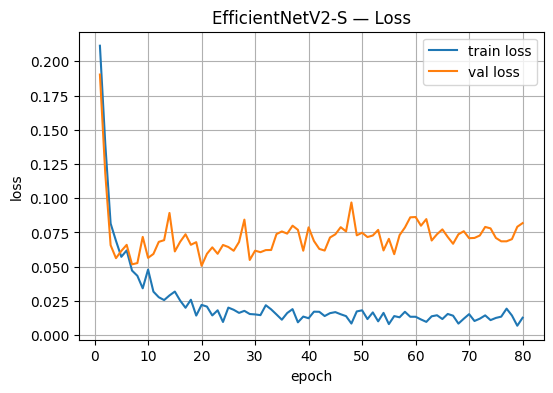

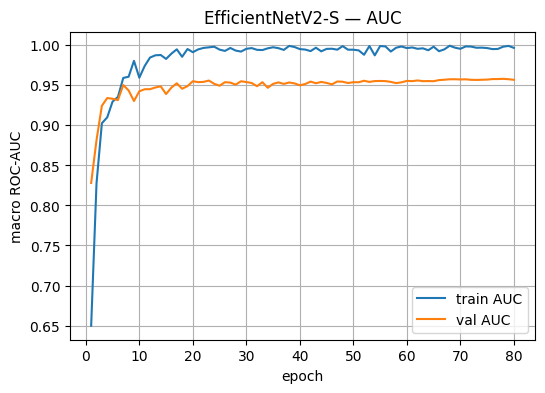

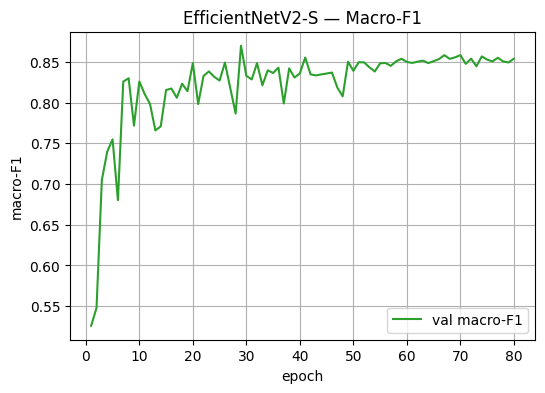

[EfficientNetV2-S] Best val macro-F1: 0.8697
=== Training ConvNeXt-Base @ 512px ===
Train class counts: {'normal': 1072, 'bacteria': 1888, 'virus': 1018, 'COVID-19': 39}
Val class counts: {'normal': 189, 'bacteria': 333, 'virus': 180, 'COVID-19': 7}
[ConvNeXt-Base] Using loss: cb_focal


[ConvNeXt-Base] Epoch 01/80 | train_loss 0.1989 AUC 0.6372 | val_loss 0.1236 AUC 0.9010 macro-F1 0.6119


[ConvNeXt-Base] Epoch 02/80 | train_loss 0.1041 AUC 0.8848 | val_loss 0.0845 AUC 0.9214 macro-F1 0.7813


[ConvNeXt-Base] Epoch 03/80 | train_loss 0.0908 AUC 0.9070 | val_loss 0.0640 AUC 0.9320 macro-F1 0.8180


[ConvNeXt-Base] Epoch 04/80 | train_loss 0.0730 AUC 0.9103 | val_loss 0.0740 AUC 0.9326 macro-F1 0.7310


...

[ConvNeXt-Base] Epoch 76/80 | train_loss 0.0117 AUC 0.9972 | val_loss 0.0759 AUC 0.9530 macro-F1 0.8617


[ConvNeXt-Base] Epoch 77/80 | train_loss 0.0155 AUC 0.9958 | val_loss 0.0757 AUC 0.9530 macro-F1 0.8620


[ConvNeXt-Base] Epoch 78/80 | train_loss 0.0163 AUC 0.9965 | val_loss 0.0756 AUC 0.9530 macro-F1 0.8587


[ConvNeXt-Base] Epoch 79/80 | train_loss 0.0107 AUC 0.9990 | val_loss 0.0756 AUC 0.9530 macro-F1 0.8587


[ConvNeXt-Base] Epoch 80/80 | train_loss 0.0133 AUC 0.9976 | val_loss 0.0756 AUC 0.9530 macro-F1 0.8587
[ConvNeXt-Base] Loaded best weights from epoch 52 (val macro-F1=0.8754).


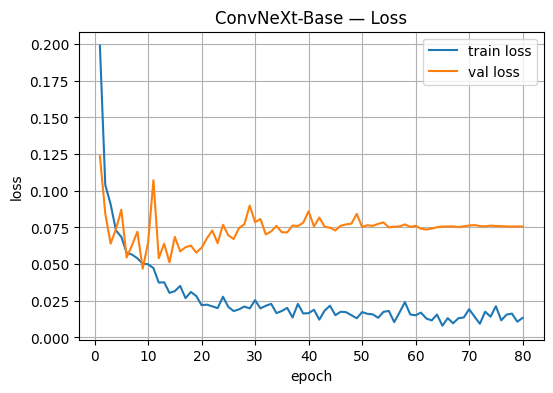

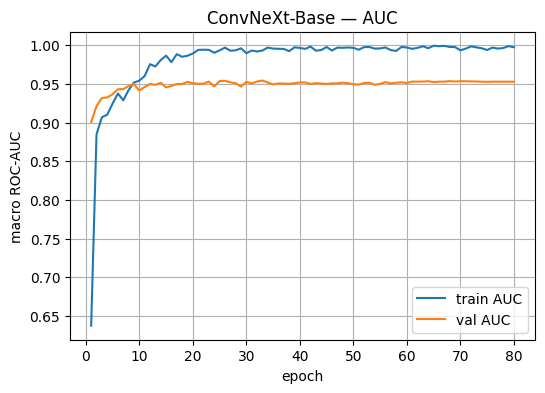

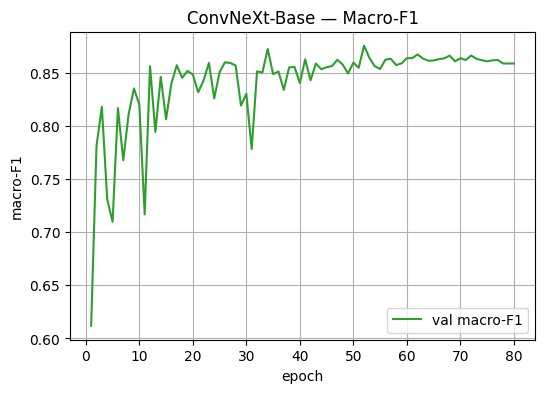

[ConvNeXt-Base] Best val macro-F1: 0.8754
=== Training Swin-V2_s @ 512px ===
Train class counts: {'normal': 1072, 'bacteria': 1888, 'virus': 1018, 'COVID-19': 39}
Val class counts: {'normal': 189, 'bacteria': 333, 'virus': 180, 'COVID-19': 7}
[Swin-V2_s] Using loss: cb_focal


[Swin-V2_s] Epoch 01/80 | train_loss 0.1857 AUC 0.7087 | val_loss 0.1278 AUC 0.9046 macro-F1 0.5220


[Swin-V2_s] Epoch 02/80 | train_loss 0.1193 AUC 0.8663 | val_loss 0.0767 AUC 0.9231 macro-F1 0.7490


[Swin-V2_s] Epoch 03/80 | train_loss 0.0925 AUC 0.8813 | val_loss 0.0928 AUC 0.9191 macro-F1 0.7157


[Swin-V2_s] Epoch 04/80 | train_loss 0.0811 AUC 0.8981 | val_loss 0.0867 AUC 0.9306 macro-F1 0.7144


...

[Swin-V2_s] Epoch 76/80 | train_loss 0.0124 AUC 0.9985 | val_loss 0.1149 AUC 0.9478 macro-F1 0.8446


[Swin-V2_s] Epoch 77/80 | train_loss 0.0154 AUC 0.9977 | val_loss 0.1138 AUC 0.9476 macro-F1 0.8476


[Swin-V2_s] Epoch 78/80 | train_loss 0.0112 AUC 0.9974 | val_loss 0.1140 AUC 0.9476 macro-F1 0.8458


[Swin-V2_s] Epoch 79/80 | train_loss 0.0179 AUC 0.9943 | val_loss 0.1140 AUC 0.9476 macro-F1 0.8458


[Swin-V2_s] Epoch 80/80 | train_loss 0.0172 AUC 0.9939 | val_loss 0.1139 AUC 0.9476 macro-F1 0.8458
[Swin-V2_s] Loaded best weights from epoch 37 (val macro-F1=0.8521).


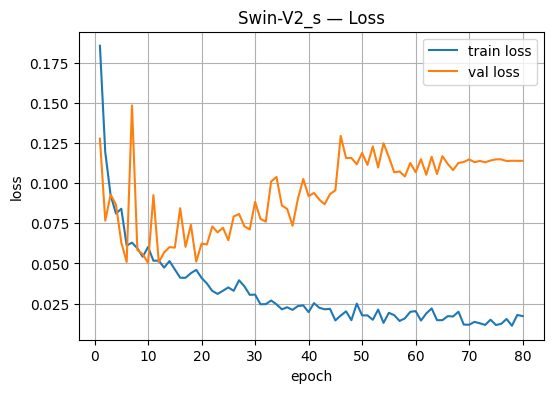

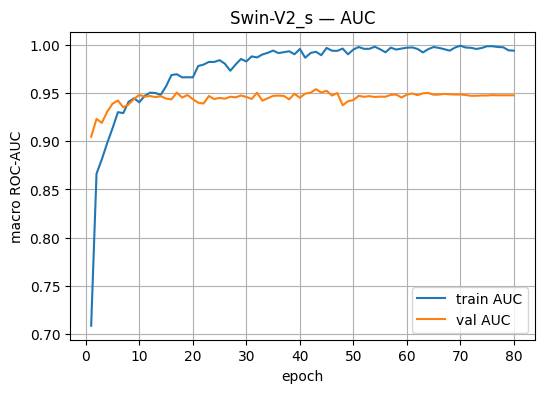

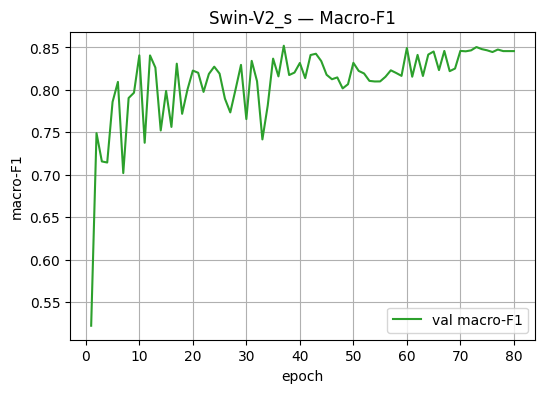

[Swin-V2_s] Best val macro-F1: 0.8521


In [17]:
import gc

histories = {}
best_states = {}

for title, model_key in MODEL_CANDIDATES:
    img_size = get_model_img_size(model_key)
    print(f"=== Training {title} @ {img_size}px ===")
    train_loader, val_loader, counts, _ = build_dataloaders(image_size=img_size)
    model = build_model(model_key, NUM_CLASSES, image_size=img_size)
    history, best_state = fit_model(
        model,
        train_loader,
        val_loader,
        title_prefix=title,
        class_counts=counts,
    )
    histories[title] = history
    best_states[title] = best_state

    del model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

In [18]:
for title, history in histories.items():
    if not history["val_f1"]:
        print(f"{title}: no validation history yet.")
        continue
    best_f1 = max(history["val_f1"])
    best_epoch = history["val_f1"].index(best_f1) + 1
    best_auc = history["val_auc"][best_epoch - 1]
    print(f"{title}: best val macro-F1={best_f1:.4f} (epoch {best_epoch}, val AUC={best_auc:.4f})")

EfficientNetV2-S: best val macro-F1=0.8697 (epoch 29, val AUC=0.9551)
ConvNeXt-Base: best val macro-F1=0.8754 (epoch 52, val AUC=0.9513)
Swin-V2_s: best val macro-F1=0.8521 (epoch 37, val AUC=0.9469)


In [19]:
# === Ensemble inference + submission ===
TEST_CSV = DATA_ROOT / "test_data_sample.csv"
SUBMISSION_PATH = DATA_ROOT / "submission.csv"


def build_test_loader(image_size: int = IMG_SIZE, batch_size: int = BATCH_SIZE, num_workers: int = NUM_WORKERS):
    _, eval_tfms_local = build_transforms(image_size)
    test_ds = TestCXRDataset(TEST_CSV, TEST_DIR, transform=eval_tfms_local, preprocess_cfg=PREPROCESS_CFG)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return test_ds, test_loader


@torch.no_grad()
def predict_single_model(model: nn.Module, loader):
    file_names, prob_chunks = [], []
    for images, names in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        prob_chunks.append(torch.softmax(logits, dim=1).cpu())
        file_names.extend(names)
    if not prob_chunks:
        return [], np.zeros((0, NUM_CLASSES), dtype=np.float32)
    all_probs = torch.cat(prob_chunks).numpy()
    return file_names, all_probs


@torch.no_grad()
def predict_ensemble(models_wrapped):
    if not models_wrapped:
        return [], np.zeros((0, NUM_CLASSES), dtype=np.float32)
    name_ref, prob_sum = None, None
    loader_cache = {}
    for title, key, model, img_size in models_wrapped:
        loader = loader_cache.get(img_size)
        if loader is None:
            _, loader = build_test_loader(image_size=img_size)
            loader_cache[img_size] = loader
        names, probs = predict_single_model(model, loader)
        if name_ref is None:
            name_ref = names
        elif names != name_ref:
            raise ValueError("Test loader orders differed across models.")
        prob_sum = probs if prob_sum is None else prob_sum + probs
    avg_probs = prob_sum / len(models_wrapped)
    return name_ref or [], avg_probs


@torch.no_grad()
def gather_logits(model: nn.Module, loader):
    logits_chunks, label_chunks = [], []
    for images, targets in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        targets_idx = ensure_class_indices(targets.to(DEVICE, non_blocking=True))
        logits = model(images)
        logits_chunks.append(logits.cpu())
        label_chunks.append(targets_idx.cpu())
    if not logits_chunks:
        return np.zeros((0, NUM_CLASSES), dtype=np.float32), np.zeros((0,), dtype=np.int64)
    all_logits = torch.cat(logits_chunks).numpy()
    all_labels = torch.cat(label_chunks).numpy()
    return all_logits, all_labels


@torch.no_grad()
def evaluate_ensemble(models_wrapped, loss_fn: nn.Module):
    if not models_wrapped:
        return float("nan"), float("nan"), float("nan")
    logit_sum, labels_ref = None, None
    loader_cache = {}
    for title, key, model, img_size in models_wrapped:
        val_loader = loader_cache.get(img_size)
        if val_loader is None:
            _, val_loader, _, _ = build_dataloaders(image_size=img_size, report_counts=False)
            loader_cache[img_size] = val_loader
        logits, labels = gather_logits(model, val_loader)
        if labels_ref is None:
            labels_ref = labels
        elif not np.array_equal(labels_ref, labels):
            raise ValueError("Validation target order mismatch across loaders.")
        logit_sum = logits if logit_sum is None else logit_sum + logits
    avg_logits = logit_sum / len(models_wrapped)
    labels_tensor = torch.from_numpy(labels_ref)
    loss = loss_fn(torch.from_numpy(avg_logits), labels_tensor).item() if labels_ref.size else float("nan")
    probs = torch.softmax(torch.from_numpy(avg_logits), dim=1).numpy()
    auc = macro_roc_auc_multiclass(labels_ref, probs) if labels_ref.size else float("nan")
    f1 = f1_score(labels_ref, probs.argmax(axis=1), average="macro") if labels_ref.size else float("nan")
    return loss, float(auc), float(f1)

def prepare_eval_model(model: nn.Module) -> nn.Module:
    model.eval()
    return build_tta_wrapper(model, TTA_MODE) if USE_TTA else model


def load_ensemble_from_states(state_map) -> list:
    models_ready = []
    for title, key in MODEL_CANDIDATES:
        state = state_map.get(title)
        if state is None:
            print(f"[Ensemble] Skipping {title}: no weights available.")
            continue
        img_size = get_model_img_size(key)
        model = build_model(key, NUM_CLASSES, image_size=img_size)
        model.load_state_dict(state)
        models_ready.append((title, key, prepare_eval_model(model), img_size))
    if not models_ready:
        print("[Ensemble] No models loaded; ensure training ran and states are available in best_states.")
    return models_ready


# Build ensemble models from in-memory best_states
ensemble_models = load_ensemble_from_states(best_states)

# Optional: evaluate ensemble on validation set
ensemble_val_loss, ensemble_val_auc, ensemble_val_f1 = evaluate_ensemble(
    ensemble_models, build_loss_fn(LOSS_NAME, train_counts, LABEL_SMOOTHING)
)
print(f"[Ensemble] Val loss {ensemble_val_loss:.4f} AUC {ensemble_val_auc:.4f} macro-F1 {ensemble_val_f1:.4f}")

[Ensemble] Val loss 0.0553 AUC 0.9609 macro-F1 0.8766


In [20]:
# Predict test set and write submission
test_names, test_probs = predict_ensemble(ensemble_models)

pred_idx = test_probs.argmax(axis=1) if len(test_probs) else []
submission_array = np.zeros((len(test_names), NUM_CLASSES), dtype=int)
if len(test_names):
    rows = np.arange(len(test_names))
    submission_array[rows, pred_idx] = 1
submission_df = pd.DataFrame(submission_array, columns=CLASS_LABELS)
submission_df.insert(0, "new_filename", test_names)

submission_df.to_csv(SUBMISSION_PATH, index=False)
print(f"[Submission] Wrote {len(submission_df)} rows to {SUBMISSION_PATH}")

[Submission] Wrote 1182 rows to /mnt/lfs0/Database/AIML_Lab/cxr-multi-label-classification/submission.csv
